# Group-AM: Hotel Booking Exploratory Data Analysis

This notebook performs exploratory data analysis on the hotel booking dataset, documents the core variables, and applies the main cleaning steps needed before modeling.

## 1. Import libraries and configure the notebook

This section imports the tools used for data loading, cleaning, summarization, and visualization.

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)

## 2. Load the dataset and inspect the raw structure

Here we load the CSV file from the project `data` folder and inspect its shape, first rows, and raw column layout.

In [12]:
data_path = "../data/hotel_bookings.csv"
df_raw = pd.read_csv(data_path)

print(f"Dataset shape: {df_raw.shape}")
display(df_raw.head())
display(df_raw.info())

Dataset shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

## 3. Describe the core variables

The dataset mixes booking timing, stay details, guest composition, commercial channel information, pricing, and final reservation outcomes. Grouping the fields makes the dataset easier to reason about before cleaning and analysis.

### Business meaning of the core variables

<table style="width: 100%; text-align: left;">
  <thead>
    <tr>
      <th style="text-align: left;">Variable(s)</th>
      <th style="text-align: left;">Business meaning</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align: left;"><code>hotel</code></td><td style="text-align: left;">Indicates whether the reservation belongs to a Resort Hotel or a City Hotel.</td></tr>
    <tr><td style="text-align: left;"><code>is_canceled</code></td><td style="text-align: left;">Shows whether the booking was canceled, which is the main target for later prediction work.</td></tr>
    <tr><td style="text-align: left;"><code>lead_time</code></td><td style="text-align: left;">Measures how many days in advance the booking was made before arrival.</td></tr>
    <tr><td style="text-align: left;"><code>arrival_date_year</code>, <code>arrival_date_month</code>, <code>arrival_date_week_number</code>, <code>arrival_date_day_of_month</code></td><td style="text-align: left;">Describe when the guest was expected to arrive.</td></tr>
    <tr><td style="text-align: left;"><code>stays_in_weekend_nights</code>, <code>stays_in_week_nights</code></td><td style="text-align: left;">Represent the length and composition of the stay.</td></tr>
    <tr><td style="text-align: left;"><code>adults</code>, <code>children</code>, <code>babies</code></td><td style="text-align: left;">Capture how many guests are covered by the reservation.</td></tr>
    <tr><td style="text-align: left;"><code>meal</code></td><td style="text-align: left;">Identifies the meal plan included in the booking.</td></tr>
    <tr><td style="text-align: left;"><code>country</code></td><td style="text-align: left;">Guest country of origin.</td></tr>
    <tr><td style="text-align: left;"><code>market_segment</code></td><td style="text-align: left;">Indicates the commercial source of the booking, such as direct, corporate, or online channels.</td></tr>
    <tr><td style="text-align: left;"><code>distribution_channel</code></td><td style="text-align: left;">Describes the booking channel used to place the reservation.</td></tr>
    <tr><td style="text-align: left;"><code>is_repeated_guest</code></td><td style="text-align: left;">Flags whether the customer has stayed with the hotel before.</td></tr>
    <tr><td style="text-align: left;"><code>previous_cancellations</code>, <code>previous_bookings_not_canceled</code></td><td style="text-align: left;">Summarize the customer's prior booking behavior.</td></tr>
    <tr><td style="text-align: left;"><code>reserved_room_type</code>, <code>assigned_room_type</code></td><td style="text-align: left;">Compare the room originally booked with the room actually assigned.</td></tr>
    <tr><td style="text-align: left;"><code>booking_changes</code></td><td style="text-align: left;">Counts how many times the reservation details were modified.</td></tr>
    <tr><td style="text-align: left;"><code>deposit_type</code></td><td style="text-align: left;">Reflects the payment commitment associated with the reservation.</td></tr>
    <tr><td style="text-align: left;"><code>agent</code>, <code>company</code></td><td style="text-align: left;">Identify a travel agent or company linked to the booking.</td></tr>
    <tr><td style="text-align: left;"><code>days_in_waiting_list</code></td><td style="text-align: left;">Measures how long the reservation stayed on a waiting list.</td></tr>
    <tr><td style="text-align: left;"><code>customer_type</code></td><td style="text-align: left;">Categorizes the booking profile, such as transient, contract, or group-related.</td></tr>
    <tr><td style="text-align: left;"><code>adr</code></td><td style="text-align: left;">Average Daily Rate, representing the average price paid per room night.</td></tr>
    <tr><td style="text-align: left;"><code>required_car_parking_spaces</code></td><td style="text-align: left;">Number of parking spaces requested.</td></tr>
    <tr><td style="text-align: left;"><code>total_of_special_requests</code></td><td style="text-align: left;">Number of extra requests made by the guest.</td></tr>
    <tr><td style="text-align: left;"><code>reservation_status</code>, <code>reservation_status_date</code></td><td style="text-align: left;">Capture the final outcome of the reservation and the date when that status was recorded.</td></tr>
  </tbody>
</table>

## 4. Profile missing values and duplicates in the raw data

Before cleaning, we check for `NULL` placeholders, standard missing values, and duplicated rows to identify the main data quality issues.

In [10]:
null_like_counts = (df_raw.eq("NULL").sum() + df_raw.isna().sum()).sort_values(ascending=False)
raw_quality = pd.DataFrame({
    "missing_or_null_like": null_like_counts,
    "missing_share": (null_like_counts / len(df_raw))
})

print(f"Duplicate rows in raw data: {df_raw.duplicated().sum()}")
display(raw_quality[raw_quality["missing_or_null_like"] > 0])

Duplicate rows in raw data: 31994


,missing_or_null_like,missing_share
company,112593,0.94
agent,16340,0.14
country,488,0.00
children,4,0.00


## 5. Clean placeholders, normalize types, and create analysis-ready fields

This cleaning step converts `NULL` strings into real missing values, fixes data types, drops the sparsely populated `company` field, converts `agent` into a presence flag, builds a proper arrival date, and creates a few useful derived features for the EDA.

In [13]:
df = df_raw.copy()

df = df.replace("NULL", np.nan)

df["children"] = pd.to_numeric(df["children"], errors="coerce")
df["agent"] = pd.to_numeric(df["agent"], errors="coerce")
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"], errors="coerce")

df["has_agent"] = df["agent"].notna().astype(int)
df = df.drop(columns=["company", "agent"])

month_map = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

df["arrival_month_num"] = df["arrival_date_month"].map(month_map)
df["arrival_date"] = pd.to_datetime(
    {
        "year": df["arrival_date_year"],
        "month": df["arrival_month_num"],
        "day": df["arrival_date_day_of_month"]
    },
    errors="coerce"
)

df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"].fillna(0) + df["babies"]
df["reserved_vs_assigned_match"] = (df["reserved_room_type"] == df["assigned_room_type"]).astype(int)

df["country"] = df["country"].fillna("Unknown")
df["children"] = df["children"].fillna(0)

print(df[["children", "has_agent", "reservation_status_date", "arrival_date", "total_nights", "total_guests"]].dtypes)
display(df.head())

children                          float64
has_agent                           int64
reservation_status_date    datetime64[ns]
arrival_date               datetime64[ns]
total_nights                        int64
total_guests                      float64
dtype: object


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,has_agent,arrival_month_num,arrival_date,total_nights,total_guests,reserved_vs_assigned_match
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,7,2015-07-01,0,2.00,1
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0,Check-Out,2015-07-01,0,7,2015-07-01,0,2.00,1
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,0,7,2015-07-01,1,1.00,0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0,Check-Out,2015-07-02,1,7,2015-07-01,1,1.00,1
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,Check-Out,2015-07-03,1,7,2015-07-01,2,2.00,1


## 6. Validate the cleaned dataset

After cleaning, we confirm the remaining missing values, verify duplicates, and inspect a compact summary of the analysis-ready table.

In [14]:
post_clean_missing = df.isna().sum().sort_values(ascending=False)

print(f"Dataset shape after cleaning: {df.shape}")
print(f"Duplicate rows after cleaning: {df.duplicated().sum()}")
display(post_clean_missing[post_clean_missing > 0])
display(df.describe(include="all").transpose().head(15))

Dataset shape after cleaning: (119390, 36)
Duplicate rows after cleaning: 32014


Series([], dtype: int64)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,"119,390.00",NaN,NaN,NaN,0.37,0.00,0.00,0.00,1.00,1.00,0.48
lead_time,"119,390.00",NaN,NaN,NaN,104.01,0.00,18.00,69.00,160.00,737.00,106.86
arrival_date_year,"119,390.00",NaN,NaN,NaN,"2,016.16","2,015.00","2,016.00","2,016.00","2,017.00","2,017.00",0.71
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,"119,390.00",NaN,NaN,NaN,27.17,1.00,16.00,28.00,38.00,53.00,13.61
arrival_date_day_of_month,"119,390.00",NaN,NaN,NaN,15.80,1.00,8.00,16.00,23.00,31.00,8.78
stays_in_weekend_nights,"119,390.00",NaN,NaN,NaN,0.93,0.00,0.00,1.00,2.00,19.00,1.00
stays_in_week_nights,"119,390.00",NaN,NaN,NaN,2.50,0.00,1.00,2.00,3.00,50.00,1.91
adults,"119,390.00",NaN,NaN,NaN,1.86,0.00,2.00,2.00,2.00,55.00,0.58


## 7. Examine the target variable and class balance

The first EDA step is to understand how often bookings are canceled and whether the target distribution is imbalanced.

,is_canceled,count,share
0,0,75166,0.63
1,1,44224,0.37


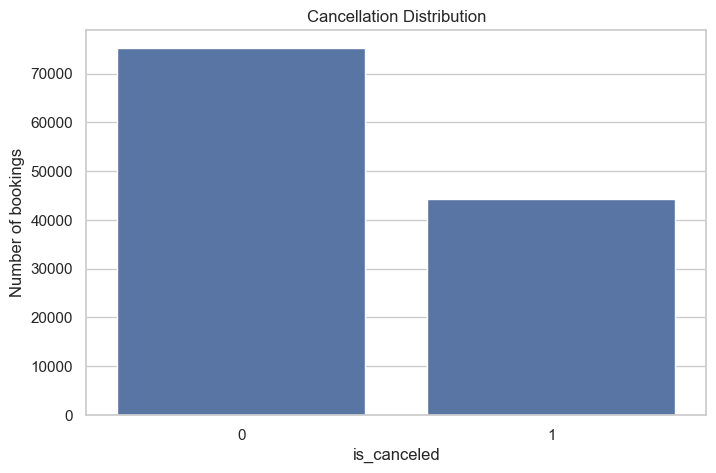

In [15]:
target_summary = (
    df["is_canceled"]
    .value_counts(normalize=False)
    .rename_axis("is_canceled")
    .reset_index(name="count")
)
target_summary["share"] = target_summary["count"] / len(df)
display(target_summary)

plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="is_canceled")
ax.set_title("Cancellation Distribution")
ax.set_xlabel("is_canceled")
ax.set_ylabel("Number of bookings")
plt.show()

## 8. Explore key numerical variables

This section summarizes the most important numerical features and visualizes their distributions to highlight skewness, spread, and possible outliers.

,count,mean,std,min,25%,50%,75%,max
lead_time,"119,390.00",104.01,106.86,0.00,18.00,69.00,160.00,737.00
adr,"119,390.00",101.83,50.54,-6.38,69.29,94.58,126.00,"5,400.00"
total_nights,"119,390.00",3.43,2.56,0.00,2.00,3.00,4.00,69.00
total_guests,"119,390.00",1.97,0.72,0.00,2.00,2.00,2.00,55.00
previous_cancellations,"119,390.00",0.09,0.84,0.00,0.00,0.00,0.00,26.00
booking_changes,"119,390.00",0.22,0.65,0.00,0.00,0.00,0.00,21.00
days_in_waiting_list,"119,390.00",2.32,17.59,0.00,0.00,0.00,0.00,391.00
total_of_special_requests,"119,390.00",0.57,0.79,0.00,0.00,0.00,1.00,5.00


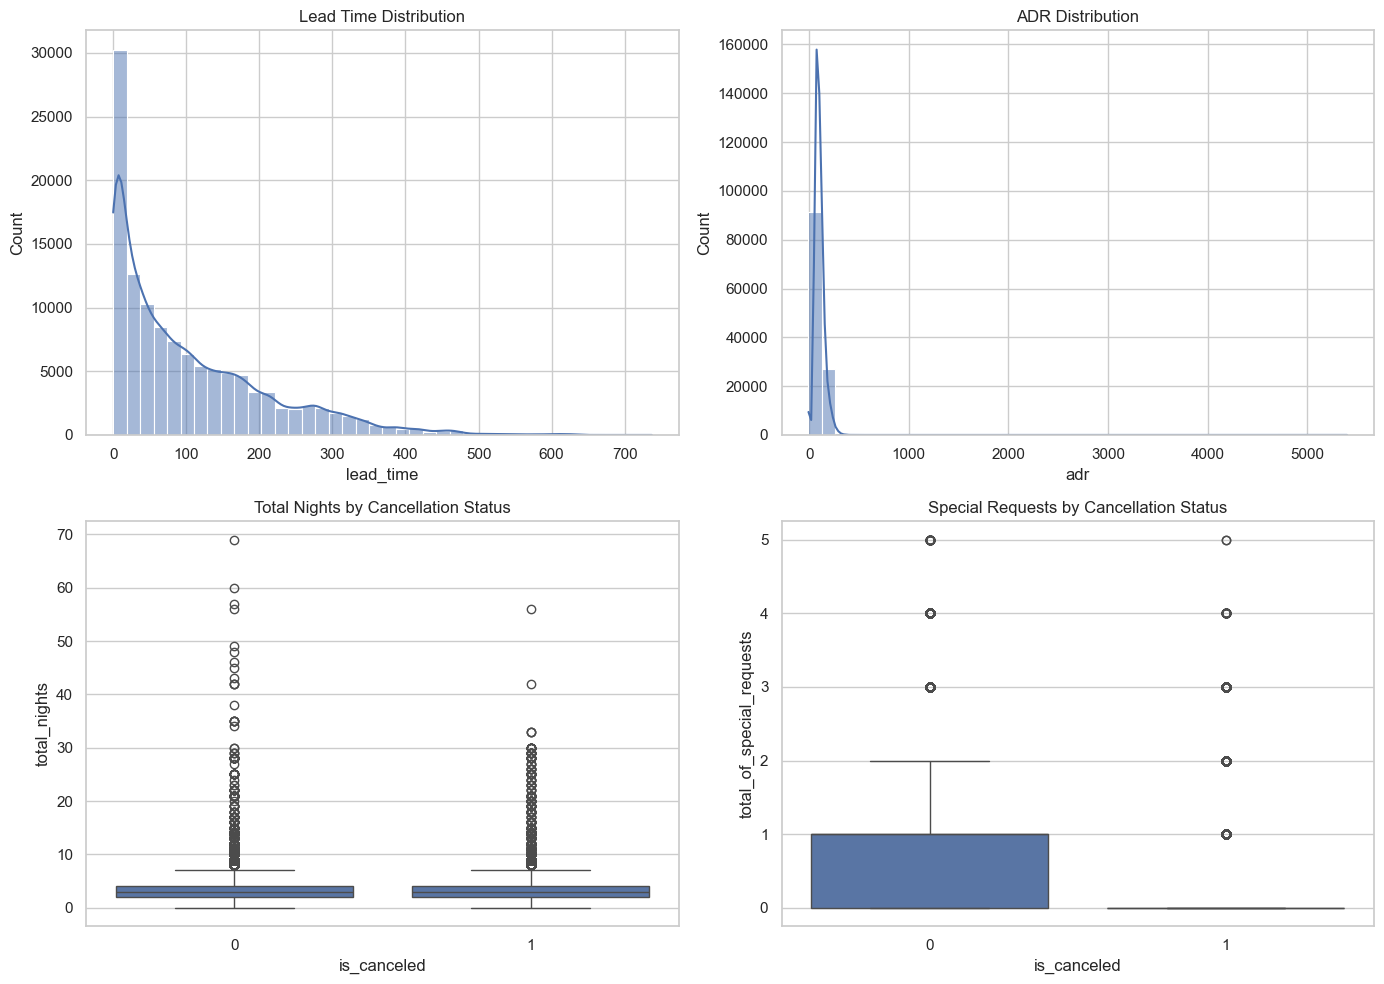

In [16]:
numerical_columns = [
    "lead_time", "adr", "total_nights", "total_guests",
    "previous_cancellations", "booking_changes", "days_in_waiting_list",
    "total_of_special_requests"
]

display(df[numerical_columns].describe().transpose())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(df["lead_time"], bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Lead Time Distribution")

sns.histplot(df["adr"], bins=40, kde=True, ax=axes[0, 1])
axes[0, 1].set_title("ADR Distribution")

sns.boxplot(data=df, x="is_canceled", y="total_nights", ax=axes[1, 0])
axes[1, 0].set_title("Total Nights by Cancellation Status")

sns.boxplot(data=df, x="is_canceled", y="total_of_special_requests", ax=axes[1, 1])
axes[1, 1].set_title("Special Requests by Cancellation Status")

plt.tight_layout()
plt.show()

### Interpretation of the numerical plots

- **Lead time** is strongly right-skewed: most bookings are made close to the arrival date, while a smaller number are made far in advance. This suggests that long booking windows may be associated with greater uncertainty and potentially higher cancellation risk.
- **ADR** is also right-skewed: most bookings fall within a typical price range, but a few observations are much higher than the rest. These extreme values may reflect premium stays, peak-season pricing, or outliers that should be treated carefully during modeling.
- **Total nights** looks fairly similar across canceled and non-canceled bookings. Most reservations are short stays, so this variable does not appear to separate the two groups strongly on its own.
- **Special requests** show a clearer pattern: non-canceled bookings tend to have more special requests, while canceled bookings are concentrated around zero. This suggests that guests who engage more with the booking process may be less likely to cancel.

## 9. Explore important categorical variables

Categorical fields such as hotel type, market segment, deposit type, and customer type often explain large differences in cancellation behavior.


Summary for hotel


,bookings,canceled_bookings,cancellation_rate
hotel,,,
City Hotel,79330,33102,0.42
Resort Hotel,40060,11122,0.28



Summary for market_segment


,bookings,canceled_bookings,cancellation_rate
market_segment,,,
Undefined,2,2,1.00
Groups,19811,12097,0.61
Online TA,56477,20739,0.37
Offline TA/TO,24219,8311,0.34
Aviation,237,52,0.22
Corporate,5295,992,0.19
Direct,12606,1934,0.15
Complementary,743,97,0.13



Summary for deposit_type


,bookings,canceled_bookings,cancellation_rate
deposit_type,,,
Non Refund,14587,14494,0.99
No Deposit,104641,29694,0.28
Refundable,162,36,0.22



Summary for customer_type


,bookings,canceled_bookings,cancellation_rate
customer_type,,,
Transient,89613,36514,0.41
Contract,4076,1262,0.31
Transient-Party,25124,6389,0.25
Group,577,59,0.10


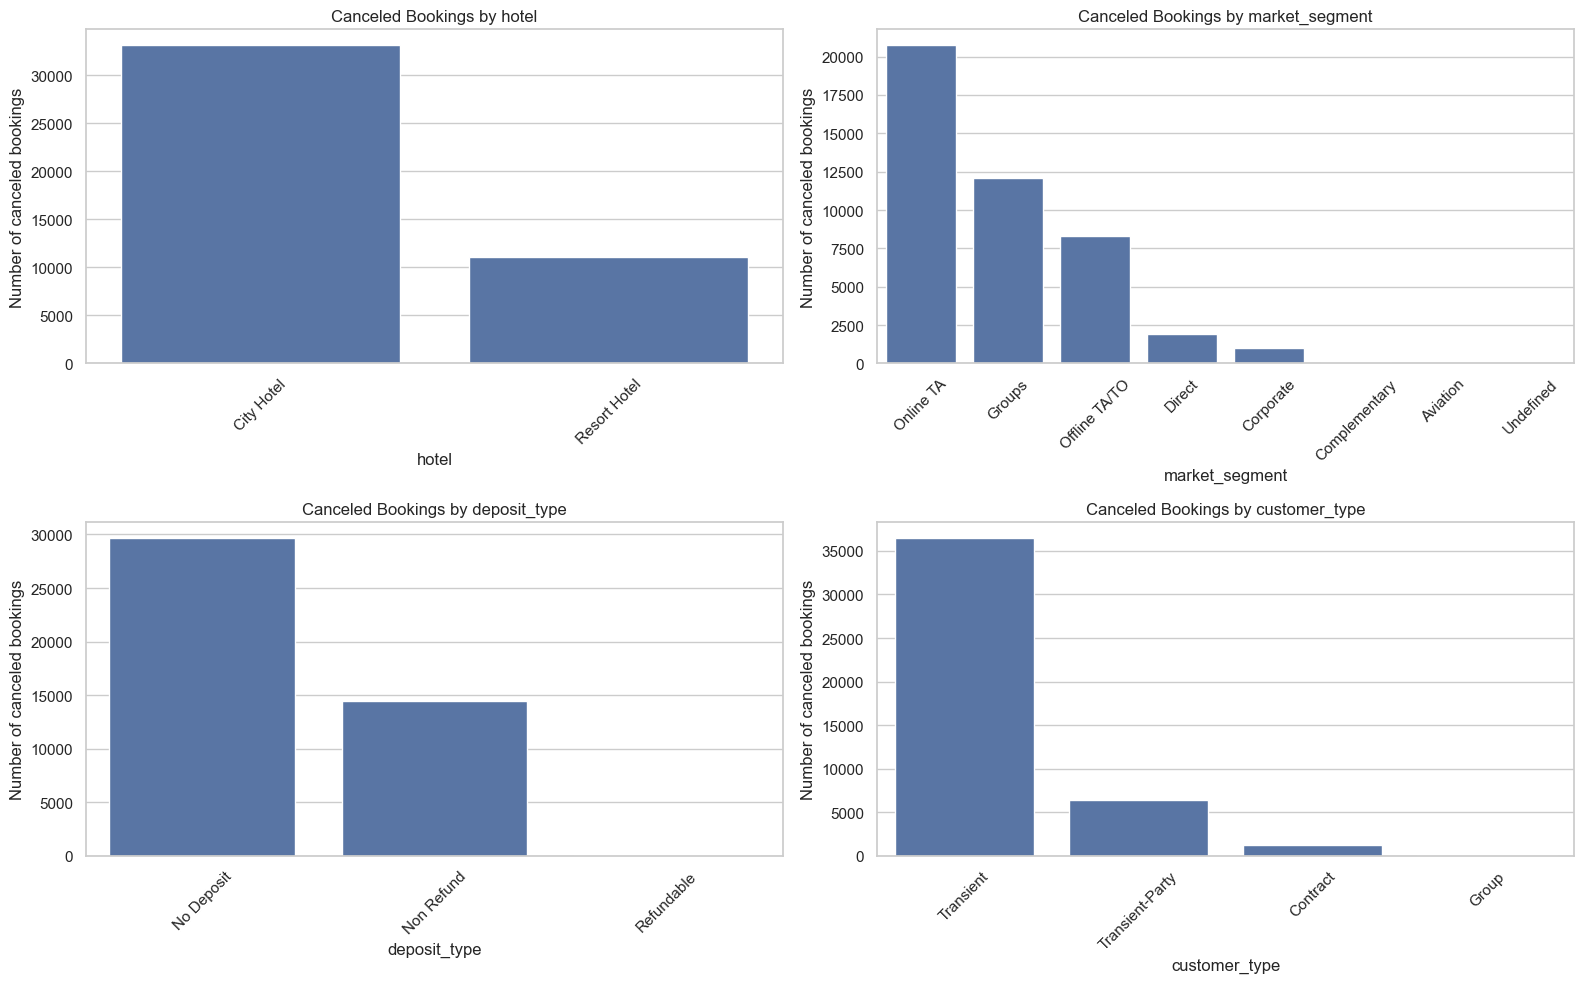

In [20]:
categorical_columns = ["hotel", "market_segment", "deposit_type", "customer_type"]

for column in categorical_columns:
    summary = (
        df.groupby(column)["is_canceled"]
        .agg(bookings="count", canceled_bookings="sum", cancellation_rate="mean")
        .sort_values("cancellation_rate", ascending=False)
    )
    print(f"\nSummary for {column}")
    display(summary.head(10))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, column in zip(axes.flatten(), categorical_columns):
    plot_data = (
        df.groupby(column)["is_canceled"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="canceled_bookings")
    )
    sns.barplot(data=plot_data, x=column, y="canceled_bookings", ax=ax, errorbar=None)
    ax.set_title(f"Canceled Bookings by {column}")
    ax.set_ylabel("Number of canceled bookings")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Interpretation of the categorical plots

- **Hotel type**: City Hotels show more canceled bookings than Resort Hotels, so the city-hotel segment contributes more to total cancellation volume.
- **Market segment**: `Online TA` contributes the highest number of canceled bookings, followed by `Groups` and `Offline TA/TO`. This means a large share of cancellation volume comes from travel-agency and group-related channels.
- **Deposit type**: `No Deposit` has the largest number of canceled bookings in absolute terms because it represents most of the dataset. `Non Refund` also shows a very large number of canceled bookings despite having far fewer total bookings, which suggests this category deserves closer investigation when comparing counts with rates.
- **Customer type**: `Transient` customers account for the largest number of canceled bookings, followed by `Transient-Party`, while `Group` contributes the fewest. This indicates cancellations are driven mainly by standard individual and small-party bookings.

## 10. Check seasonality and monthly booking patterns

Booking demand and cancellations can vary over time, so this section looks at arrivals by month and the associated cancellation rate.

,bookings,cancellation_rate
arrival_date_month,,
January,5929,0.30
February,8068,0.33
March,9794,0.32
April,11089,0.41
May,11791,0.40
June,10939,0.41
July,12661,0.37
August,13877,0.38
September,10508,0.39


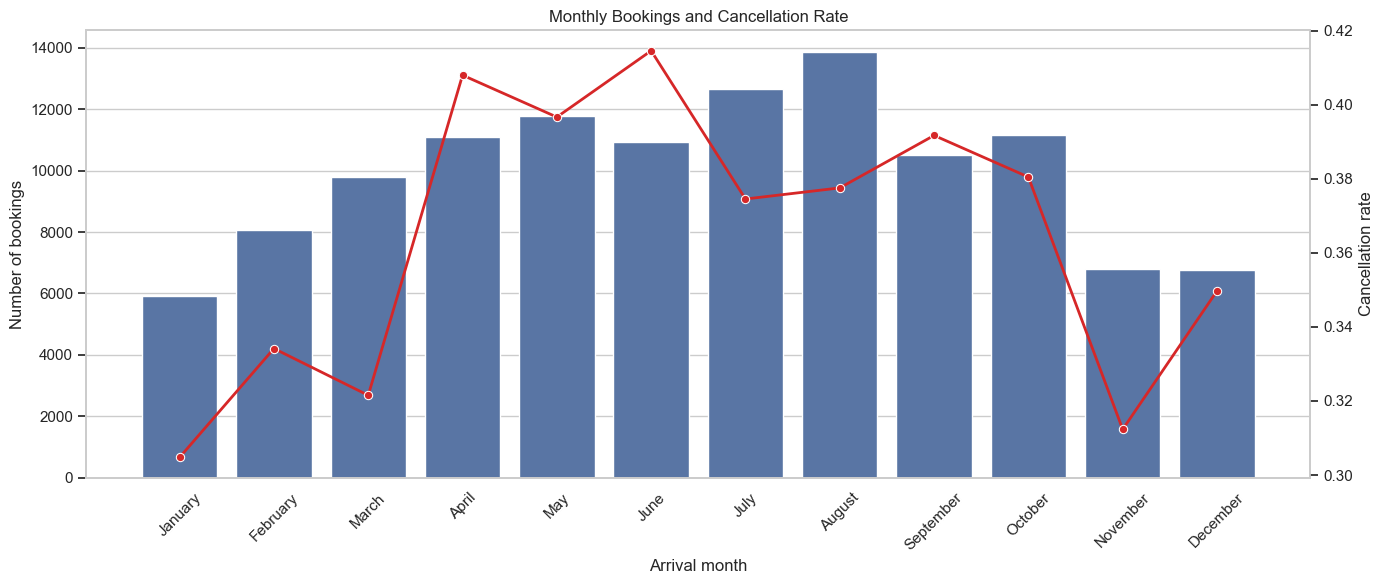

In [22]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

monthly_summary = (
    df.groupby("arrival_date_month")["is_canceled"]
    .agg(bookings="count", cancellation_rate="mean")
    .reindex(month_order)
)
display(monthly_summary)

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(x=monthly_summary.index, y=monthly_summary["bookings"], ax=ax1, color=sns.color_palette()[0])
ax1.set_title("Monthly Bookings and Cancellation Rate")
ax1.set_xlabel("Arrival month")
ax1.set_ylabel("Number of bookings")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
sns.lineplot(x=monthly_summary.index, y=monthly_summary["cancellation_rate"], ax=ax2, color="#d62728", marker="o", linewidth=2)
ax2.set_ylabel("Cancellation rate")
ax2.grid(False)

plt.tight_layout()
plt.show()

### Interpretation of the monthly bookings and cancellation chart

- Booking volume increases from January toward the summer period, with the highest number of bookings appearing in **August**. This indicates clear seasonality in hotel demand.
- The **cancellation rate** does not move exactly in line with total bookings. It rises sharply in **April** and stays relatively high through **June**, where it reaches one of its highest points.
- During **July** and **August**, booking volume is very high but the cancellation rate is slightly lower than the late-spring peak. This suggests that busy months do not automatically have the highest cancellation risk.
- **November** has one of the lowest cancellation rates and also a lower number of bookings, while **December** shows a small increase again.

Overall, the graph suggests that **seasonality affects both demand and cancellation behavior**, but not in exactly the same way. This means arrival month is likely to be a useful predictive feature.

## 11. Review correlations among numerical features

A correlation heatmap helps identify variables that move together and highlights numeric features that may be useful during feature engineering or modeling.

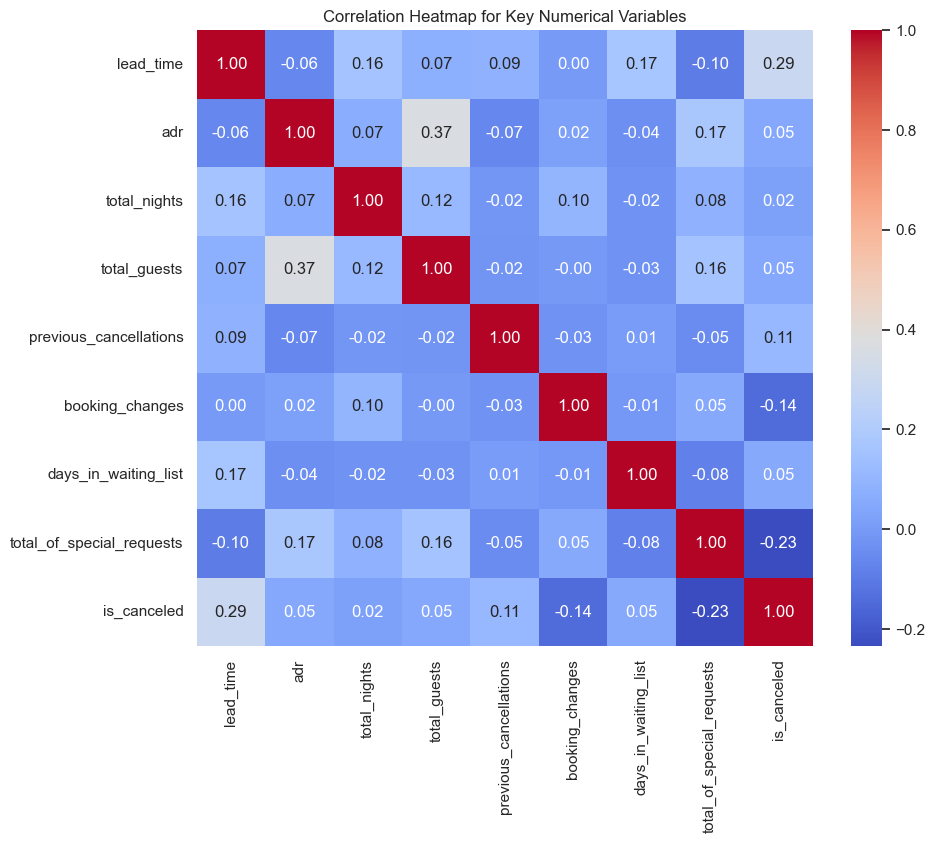

Correlations with the target variable:


is_canceled                  1.00
lead_time                    0.29
previous_cancellations       0.11
days_in_waiting_list         0.05
adr                          0.05
total_guests                 0.05
total_nights                 0.02
booking_changes             -0.14
total_of_special_requests   -0.23
Name: is_canceled, dtype: float64

In [25]:
corr_columns = numerical_columns + ["is_canceled"]
corr_matrix = df[corr_columns].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap for Key Numerical Variables")
plt.show()

print("Correlations with the target variable:")
corr_with_target = corr_matrix["is_canceled"].sort_values(ascending=False)
display(corr_with_target)

### Interpretation of the correlation heatmap

- Most correlations are **weak to moderate**, which suggests the numerical variables are not heavily redundant and each one may contribute different information.
- The strongest positive correlation with `is_canceled` is **`lead_time` (about 0.29)**. Bookings made further in advance tend to be more likely to cancel.
- `previous_cancellations` also has a positive relationship with cancellation (**about 0.11**), which supports the idea that past behavior is useful for predicting future cancellations.
- The strongest negative correlation with `is_canceled` is **`total_of_special_requests` (about -0.24)**. Guests who make more requests tend to be less likely to cancel.
- `booking_changes` is also negatively correlated with cancellation (**about -0.14**), which may indicate that guests who adjust their bookings are still engaged and more likely to keep them.

Overall, the heatmap suggests that **lead time, special requests, previous cancellations, and booking changes** are among the most informative numerical signals in the dataset.

## 12. Summarize the main EDA findings

This final section captures the main observations from the cleaning and exploration steps in a compact, business-focused format.

### Summary overview

| Metric | Value |
| :--- | :--- |
| Rows | 119,390 |
| Columns after cleaning | 36 |
| Cancellation rate | 37.04% |
| Duplicate rows still present | 32,014 |
| Average lead time | 104.01 days |
| Average ADR | 101.83 |
| Average total nights | 3.43 |
| Bookings with an agent | 86.31% |

### Main EDA findings

| Theme | Finding | Business meaning |
| :--- | :--- | :--- |
| Data quality | The dataset needed light structural cleaning: `NULL` placeholders were standardized, `company` was dropped, `agent` was converted into a presence flag, and date-based features were created. | The dataset is usable for modeling, but duplicate handling should still be decided before training. |
| Target balance | About 37.04% of bookings were canceled, so the problem is moderately imbalanced. | Accuracy alone is not enough; ROC-AUC, recall, precision, and F1 are more informative. |
| Numerical cancellation signal | `lead_time` is the strongest positive numerical signal for cancellation, with correlation around `0.29`. | Long lead-time bookings should be monitored more closely because they carry more uncertainty. |
| Protective engagement signal | `total_of_special_requests` is the strongest negative numerical signal for cancellation, with correlation around `-0.24`. | Guests who make requests appear more committed, which can help separate likely stays from likely cancellations. |
| Hotel segment | City Hotel contributes the largest cancellation volume with 33,102 canceled bookings. | Cancellation mitigation efforts may need to be stronger for city hotels than for resort hotels. |
| Market segment | `Online TA` generates the highest number of canceled bookings with 20,739 cancellations. | Channel strategy matters because a large share of cancellations is concentrated in OTA-driven bookings. |
| Deposit policy | `No Deposit` contributes the highest cancellation volume with 29,694 canceled bookings. | Deposit policy is an important commercial control and should be studied alongside both booking volume and cancellation probability. |
| Customer type | `Transient` customers account for the highest cancellation volume with 36,514 cancellations. | Retention efforts should focus first on standard individual bookings because they drive most cancellations. |
| Seasonality | Booking demand peaks in summer, especially August, while cancellation rate peaks earlier around April to June. | Arrival month should remain in the feature set because timing influences both demand and cancellation behavior. |